In [3]:
import matplotlib.pyplot as plt
import pandas as pd


In [4]:
path = '/home/markakis/chunkbench/data/cab_workloads/cab_factor1_hours4_seed1_dbs20_streams20/cab_factor1_hours4_seed1_dbs20_streams20.parquet'

df = pd.read_parquet(path)
df.head()

,query_id,stream_id,rel_start_time_s,query_template,query_num_within_template,query_text
0,11_2,11,17.865,8,0,-- Filename: query008_000.sql\nselect\n\to_yea...
1,16_0,16,19.137,14,0,-- Filename: query014_000.sql\nselect\n\t100.0...
2,5_0,5,20.191,14,0,-- Filename: query014_000.sql\nselect\n\t100.0...
3,2_2,2,20.241,12,0,-- Filename: query012_000.sql\nselect\n\tl_shi...
4,19_0,19,23.398,18,0,-- Filename: query018_000.sql\nselect\n\tc_nam...


In [5]:
# Plot query arrivals over time per 1 minute interval
def plot_stream_query_arrivals(df, stream_id=None):
    if stream_id is not None:
        df = df[df['stream_id'] == stream_id]
    df['arrival_time'] = pd.to_datetime(df['rel_start_time_s'], unit='s')
    df.set_index('arrival_time', inplace=True)
    query_arrivals = df.resample('1T').size()
    plt.figure(figsize=(12, 6))
    plt.plot(query_arrivals.index, query_arrivals.values, marker='o')
    plt.title('Query Arrivals Over Time (1 Minute Intervals)')
    plt.xlabel('Time')
    plt.ylabel('Number of Queries')
    plt.grid(True)
    plt.show()

/tmp/ipykernel_3357711/1280548603.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['arrival_time'] = pd.to_datetime(df['rel_start_time_s'], unit='s')
/tmp/ipykernel_3357711/1280548603.py:7: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  query_arrivals = df.resample('1T').size()


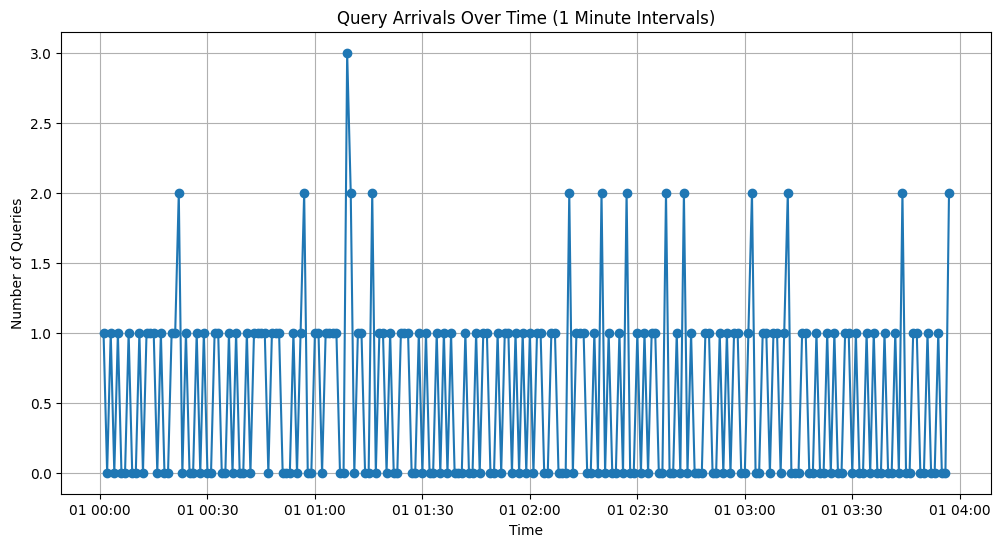

In [9]:
plot_stream_query_arrivals(df, stream_id=3)

In [11]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Optional, Sequence, Dict, Any, Tuple, List

import numpy as np
import pandas as pd

# If sklearn isn't available in your env, you can swap PoissonRegressor with a simple
# gradient step; but sklearn is usually present.
from sklearn.linear_model import PoissonRegressor
from sklearn.preprocessing import StandardScaler


# ----------------------------
# Utilities: time grid + binning
# ----------------------------

def _make_time_grid(times: np.ndarray, dt: float) -> Tuple[np.ndarray, float]:
    """
    Create a uniform grid [0, T] with spacing dt (seconds).
    Returns:
      grid_centers: shape (G,)
      T: end time (max observed, rounded up to grid)
    """
    tmax = float(np.max(times))
    T = dt * np.ceil(tmax / dt)
    edges = np.arange(0.0, T + dt, dt)
    centers = edges[:-1] + 0.5 * dt
    return centers, T


def _bin_counts(times: np.ndarray, dt: float, T: float) -> Tuple[np.ndarray, np.ndarray]:
    """
    Bin events into counts per dt bin over [0, T).
    Returns:
      counts: shape (G,)
      bin_idx: shape (N,) giving bin index for each event (clipped to range)
    """
    G = int(np.round(T / dt))
    bin_idx = np.floor(times / dt).astype(int)
    bin_idx = np.clip(bin_idx, 0, G - 1)
    counts = np.bincount(bin_idx, minlength=G).astype(float)
    return counts, bin_idx


# ----------------------------
# Basis functions for log-intensity models
# ----------------------------

def design_matrix_constant(grid_t: np.ndarray) -> np.ndarray:
    """Constant intensity: log λ(t) = θ0."""
    return np.ones((grid_t.shape[0], 1), dtype=float)


def design_matrix_fourier(grid_t: np.ndarray, period_s: float, n_harmonics: int) -> np.ndarray:
    """
    Periodic intensity: log λ(t) = a0 + Σ_m [a_m cos(2π m t/P) + b_m sin(2π m t/P)].
    """
    t = grid_t.reshape(-1, 1)
    cols = [np.ones_like(t)]
    for m in range(1, n_harmonics + 1):
        w = 2.0 * np.pi * m / period_s
        cols.append(np.cos(w * t))
        cols.append(np.sin(w * t))
    return np.concatenate(cols, axis=1)


def design_matrix_bspline(grid_t: np.ndarray, n_knots: int, degree: int = 3) -> np.ndarray:
    """
    Simple B-spline basis over time for bursty/nonstationary components.
    Implemented via truncated power basis (a common spline basis) without scipy.
    This is not a full-fledged spline library, but works well for NHPP intensity modeling.

    log λ(t) = θ0 + θ1 t + ... + θ_degree t^degree + Σ_j γ_j (t - κ_j)^degree_+
    where κ_j are interior knots and (u)_+ = max(u, 0).
    """
    t = grid_t.astype(float)
    t_scaled = (t - t.min()) / max(1e-9, (t.max() - t.min()))
    G = t.shape[0]

    # Interior knots on [0,1]
    # n_knots counts interior knots; endpoints handled by polynomial part.
    if n_knots <= 0:
        # Pure polynomial
        cols = [np.ones(G)]
        for p in range(1, degree + 1):
            cols.append(t_scaled**p)
        return np.vstack(cols).T

    knots = np.linspace(0.0, 1.0, n_knots + 2)[1:-1]  # interior only
    cols = [np.ones(G)]
    for p in range(1, degree + 1):
        cols.append(t_scaled**p)
    for k in knots:
        cols.append(np.maximum(t_scaled - k, 0.0) ** degree)
    X = np.vstack(cols).T
    return X


# ----------------------------
# Softmax regression for feature-dependent mixture weights π_k(x)
# (trained with responsibilities)
# ----------------------------

def _softmax(Z: np.ndarray) -> np.ndarray:
    Z = Z - Z.max(axis=1, keepdims=True)
    expZ = np.exp(Z)
    return expZ / np.clip(expZ.sum(axis=1, keepdims=True), 1e-12, None)


def fit_softmax_with_responsibilities(
    X: np.ndarray,
    R: np.ndarray,
    l2: float = 1e-2,
    lr: float = 0.1,
    n_steps: int = 500,
    seed: int = 0,
) -> np.ndarray:
    """
    Fit W to maximize Σ_i Σ_k R[i,k] log softmax(XW)[i,k] - (l2/2)||W||^2
    using simple gradient descent.

    X: (N, D)
    R: (N, K) responsibilities (rows sum to 1)
    returns W: (D, K)
    """
    rng = np.random.default_rng(seed)
    N, D = X.shape
    K = R.shape[1]

    W = 0.01 * rng.standard_normal((D, K))

    for _ in range(n_steps):
        P = _softmax(X @ W)  # (N,K)
        # Gradient: X^T (P - R) / N + l2 * W
        grad = (X.T @ (P - R)) / max(1, N) + l2 * W
        W -= lr * grad

    return W


# ----------------------------
# Mixture of NHPP components (EM on discretized grid)
# ----------------------------

@dataclass
class ComponentSpec:
    """
    Defines one component family.
    kind:
      - "background": constant log-intensity
      - "periodic": Fourier log-intensity
      - "bursty": spline log-intensity
    """
    kind: str
    period_s: Optional[float] = None
    n_harmonics: int = 3
    n_knots: int = 12
    spline_degree: int = 3
    ridge_alpha: float = 1e-6  # regularization inside PoissonRegressor


@dataclass
class MixtureNHPPResult:
    specs: List[ComponentSpec]
    dt: float
    T: float
    grid_t: np.ndarray                # (G,)
    lambda_grid: np.ndarray           # (K,G) intensity per component at each grid center
    integral_lambda: np.ndarray       # (K,) integral over [0,T] (approx)
    responsibilities: np.ndarray      # (N,K)
    hard_assignments: np.ndarray      # (N,)
    pi_feature_weights: Optional[np.ndarray]  # (D,K) if features used
    feature_scaler: Optional[StandardScaler]


def _build_design_for_component(spec: ComponentSpec, grid_t: np.ndarray) -> np.ndarray:
    if spec.kind == "background":
        return design_matrix_constant(grid_t)
    if spec.kind == "periodic":
        if spec.period_s is None:
            raise ValueError("periodic component requires period_s")
        return design_matrix_fourier(grid_t, spec.period_s, spec.n_harmonics)
    if spec.kind == "bursty":
        return design_matrix_bspline(grid_t, n_knots=spec.n_knots, degree=spec.spline_degree)
    raise ValueError(f"Unknown component kind: {spec.kind}")


def _fit_poisson_glm_weighted(
    X: np.ndarray, y_counts: np.ndarray, sample_weight: np.ndarray, alpha: float
) -> np.ndarray:
    """
    Fit Poisson regression for counts with log link:
      y ~ Poisson(exp(Xθ) * dt)
    Since y are per-bin counts, this is a standard Poisson GLM.

    Returns θ.
    """
    # PoissonRegressor fits y ~ Poisson(exp(Xθ + intercept)).
    # We already include intercept in X, so set fit_intercept=False.
    model = PoissonRegressor(alpha=alpha, fit_intercept=False, max_iter=500)
    model.fit(X, y_counts, sample_weight=sample_weight)
    return model.coef_.copy()


def fit_mixture_nhpp_em(
    df: pd.DataFrame,
    time_col: str = "rel_start_time_s",
    feature_cols: Optional[Sequence[str]] = None,
    specs: Optional[List[ComponentSpec]] = None,
    dt: float = 5.0,
    n_iters: int = 30,
    use_feature_dependent_pi: bool = True,
    softmax_l2: float = 1e-2,
    softmax_lr: float = 0.2,
    softmax_steps: int = 400,
    seed: int = 0,
    eps: float = 1e-12,
) -> MixtureNHPPResult:
    """
    Learn a mixture of NHPP components from arrival times using EM.

    Likelihood (for component k):
      log p({t_i}) = Σ_i log λ_k(t_i) - ∫_0^T λ_k(t) dt

    We approximate λ_k(t) on a grid (dt), and evaluate λ_k(t_i) by bin lookup.

    If feature_cols is provided and use_feature_dependent_pi=True, we learn:
      π_k(x_i) = softmax(x_i^T W)_k
    Otherwise π_k is a global mixing weight learned from responsibilities.

    Returns MixtureNHPPResult with responsibilities and fitted intensities.
    """
    rng = np.random.default_rng(seed)
    times = df[time_col].to_numpy(dtype=float)
    if times.ndim != 1 or len(times) == 0:
        raise ValueError("time_col must be a non-empty 1D column of times.")
    if np.any(times < 0):
        raise ValueError("Expected non-negative relative times.")

    # Default components: 1 background, 1 periodic (you set period), 2 bursty
    if specs is None:
        specs = [
            ComponentSpec(kind="background"),
            ComponentSpec(kind="bursty", n_knots=10),
            ComponentSpec(kind="bursty", n_knots=18),
        ]

    K = len(specs)
    grid_t, T = _make_time_grid(times, dt=dt)
    counts, bin_idx = _bin_counts(times, dt=dt, T=T)
    G = len(grid_t)

    # Precompute design matrices per component
    Xk_list = [_build_design_for_component(spec, grid_t) for spec in specs]
    pk = np.array([X.shape[1] for X in Xk_list], dtype=int)

    # Initialize λ_k(grid) roughly
    # Start with uniform + small random noise to break symmetry
    base_rate = len(times) / max(T, 1e-9)  # events per second
    lambda_grid = np.clip(base_rate * (1.0 + 0.1 * rng.standard_normal((K, G))), 1e-6, None)

    # Mixture weights initialization
    global_pi = np.ones(K, dtype=float) / K

    # Features for π_k(x)
    W = None
    scaler = None
    Xfeat = None
    if feature_cols is not None and len(feature_cols) > 0:
        Xfeat_raw = df[list(feature_cols)].to_numpy(dtype=float)
        scaler = StandardScaler()
        Xfeat = scaler.fit_transform(Xfeat_raw)
        # Add intercept
        Xfeat = np.concatenate([np.ones((Xfeat.shape[0], 1)), Xfeat], axis=1)
        W = 0.01 * rng.standard_normal((Xfeat.shape[1], K))

    def eval_log_lambda_at_events(lambda_grid_k: np.ndarray) -> np.ndarray:
        # Lookup λ at the bin containing each event
        lam = lambda_grid_k[bin_idx]
        return np.log(np.clip(lam, eps, None))

    for it in range(n_iters):
        # ---- E-step: responsibilities r_ik ∝ π_k(x_i) * λ_k(t_i) * exp(-∫λ_k)
        integral_lambda = lambda_grid.sum(axis=1) * dt  # (K,)

        log_pi = None
        if Xfeat is not None and use_feature_dependent_pi and W is not None:
            log_pi = np.log(np.clip(_softmax(Xfeat @ W), eps, None))  # (N,K)
        else:
            log_pi = np.log(np.clip(global_pi, eps, None))[None, :]   # (1,K)

        loglik_events = np.zeros((len(times), K), dtype=float)
        for k in range(K):
            loglik_events[:, k] = eval_log_lambda_at_events(lambda_grid[k]) - integral_lambda[k]

        # Combine with mixing weights
        if log_pi.shape[0] == 1:
            log_post = loglik_events + log_pi
        else:
            log_post = loglik_events + log_pi

        # Normalize
        log_post = log_post - log_post.max(axis=1, keepdims=True)
        post = np.exp(log_post)
        R = post / np.clip(post.sum(axis=1, keepdims=True), eps, None)  # (N,K)

        # ---- M-step:
        # (a) Update component intensities via weighted Poisson regression on binned counts.
        # For NHPP, expected count per bin for component k is:
        #   y_k[g] = Σ_{i in bin g} R[i,k]
        # We fit counts ~ Poisson(exp(Xθ) * dt); since dt is constant, it’s absorbed in θ0.
        # We implement this by fitting y_k as the target counts.
        Yk = np.zeros((K, G), dtype=float)
        for i in range(len(times)):
            Yk[:, bin_idx[i]] += R[i, :]

        # Fit each component separately on grid bins
        new_lambda_grid = np.zeros_like(lambda_grid)
        for k in range(K):
            Xk = Xk_list[k]
            yk = Yk[k]  # fractional expected counts per bin
            # Weights: you can weight bins by total counts to emphasize dense regions, but 1 works fine.
            w_bins = np.ones(G, dtype=float)

            theta = _fit_poisson_glm_weighted(
                X=Xk,
                y_counts=yk,
                sample_weight=w_bins,
                alpha=specs[k].ridge_alpha,
            )
            log_rate = Xk @ theta
            lam = np.exp(np.clip(log_rate, -30, 30)) / max(dt, 1e-9)  # convert "per bin" to "per second"
            new_lambda_grid[k] = np.clip(lam, 1e-9, None)

        lambda_grid = new_lambda_grid

        # (b) Update mixing weights
        if Xfeat is not None and use_feature_dependent_pi and W is not None:
            W = fit_softmax_with_responsibilities(
                X=Xfeat,
                R=R,
                l2=softmax_l2,
                lr=softmax_lr,
                n_steps=softmax_steps,
                seed=seed + it,
            )
        else:
            global_pi = np.clip(R.mean(axis=0), eps, None)
            global_pi = global_pi / global_pi.sum()

    # Final responsibilities + assignments
    integral_lambda = lambda_grid.sum(axis=1) * dt
    log_pi_final = None
    if Xfeat is not None and use_feature_dependent_pi and W is not None:
        log_pi_final = np.log(np.clip(_softmax(Xfeat @ W), eps, None))
    else:
        log_pi_final = np.log(np.clip(global_pi, eps, None))[None, :]

    loglik_events = np.zeros((len(times), K), dtype=float)
    for k in range(K):
        loglik_events[:, k] = np.log(np.clip(lambda_grid[k][bin_idx], eps, None)) - integral_lambda[k]

    if log_pi_final.shape[0] == 1:
        log_post = loglik_events + log_pi_final
    else:
        log_post = loglik_events + log_pi_final

    log_post = log_post - log_post.max(axis=1, keepdims=True)
    post = np.exp(log_post)
    R = post / np.clip(post.sum(axis=1, keepdims=True), eps, None)

    hard = np.argmax(R, axis=1)

    return MixtureNHPPResult(
        specs=specs,
        dt=dt,
        T=T,
        grid_t=grid_t,
        lambda_grid=lambda_grid,
        integral_lambda=integral_lambda,
        responsibilities=R,
        hard_assignments=hard,
        pi_feature_weights=W,
        feature_scaler=scaler,
    )


# ----------------------------
# (Optional) quick-and-dirty period candidates from counts FFT
# ----------------------------

def suggest_periods_from_fft(df: pd.DataFrame, time_col: str, dt: float, top_k: int = 5) -> List[float]:
    """
    Suggest candidate periods by FFT on binned counts.
    Returns periods in seconds (excluding DC).
    """
    times = df[time_col].to_numpy(dtype=float)
    grid_t, T = _make_time_grid(times, dt=dt)
    counts, _ = _bin_counts(times, dt=dt, T=T)

    x = counts - counts.mean()
    X = np.fft.rfft(x)
    freqs = np.fft.rfftfreq(len(x), d=dt)

    # Exclude 0 frequency
    power = (X.real**2 + X.imag**2)
    power[0] = 0.0

    idx = np.argsort(power)[::-1]
    periods = []
    for j in idx[: 10 * top_k]:
        f = freqs[j]
        if f <= 0:
            continue
        P = 1.0 / f
        if np.isfinite(P) and P > 2 * dt:
            periods.append(P)
        if len(periods) >= top_k:
            break
    return periods


In [18]:
df3 = df[df['stream_id'] == 3].copy()

# 1) Optional: look for periodicities
periods = suggest_periods_from_fft(df3, "rel_start_time_s", dt=10.0, top_k=5)
print("Candidate periods (s):", periods)

# 2) Define components (example: background + a daily-ish periodic + 2 bursty)
# Suppose your rel times are within a day and dt=10s; you might try P=3600 or 86400 etc.
specs = [
    ComponentSpec(kind="background"),
    ComponentSpec(kind="periodic", period_s=3600.0, n_harmonics=4),  # 1-hour periodic
    ComponentSpec(kind="bursty", n_knots=12),
    ComponentSpec(kind="bursty", n_knots=24),
]

result = fit_mixture_nhpp_em(
    df3,
    time_col="rel_start_time_s",
    feature_cols=["query_template"],  # numeric/encoded
    specs=specs,
    dt=10.0,
    n_iters=25,
    use_feature_dependent_pi=True,
)

df3["process_id"] = result.hard_assignments
df3.head()

Candidate periods (s): [np.float64(46.48208469055375), np.float64(82.96511627906976), np.float64(21.987673343605547), np.float64(33.4192037470726), np.float64(41.48255813953488)]


,query_id,stream_id,rel_start_time_s,query_template,query_num_within_template,query_text,process_id
12,3_1,3,81.642,3,0,-- Filename: query003_000.sql\nselect\n ...,2
18,3_2,3,185.535,8,0,-- Filename: query008_000.sql\nselect\n\to_yea...,2
37,3_0,3,342.976,4,0,-- Filename: query004_000.sql\nselect\n\to_ord...,2
50,3_9,3,527.806,16,0,-- Filename: query016_000.sql\nselect\n\tp_bra...,2
64,3_5,3,693.255,19,0,-- Filename: query019_000.sql\nselect\n\tsum(l...,2


In [19]:
df3.groupby("process_id").size()

process_id
2    130
dtype: int64

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def plot_arrivals_raster(
    df: pd.DataFrame,
    time_col: str,
    process_col: str = "process_id",
    alpha: float = 0.35,
    figsize=(12, 2.2),
):
    """
    Raster plot: each arrival is a vertical tick, colored by inferred process.
    """
    t = df[time_col].to_numpy(float)
    z = df[process_col].to_numpy(int)

    fig, ax = plt.subplots(figsize=figsize)
    # one y-level; color carries the info
    ax.scatter(t, np.zeros_like(t), c=z, s=12, marker="|", alpha=alpha)
    ax.set_yticks([])
    ax.set_xlabel("Time (s)")
    ax.set_title("Arrivals colored by inferred process")
    plt.tight_layout()
    return fig, ax


def plot_arrivals_per_process_rows(
    df: pd.DataFrame,
    time_col: str,
    process_col: str = "process_id",
    n_processes: int | None = None,
    alpha: float = 0.6,
    figsize=(12, 3.5),
):
    """
    Raster plot with one row per process (easier to read when K>2).
    """
    t = df[time_col].to_numpy(float)
    z = df[process_col].to_numpy(int)

    if n_processes is None:
        n_processes = int(z.max()) + 1

    fig, ax = plt.subplots(figsize=figsize)
    for k in range(n_processes):
        tk = t[z == k]
        if len(tk) == 0:
            continue
        ax.scatter(tk, np.full_like(tk, k), s=14, marker="|", alpha=alpha)

    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Process id")
    ax.set_yticks(range(n_processes))
    ax.set_title("Arrivals split into inferred processes (one row per process)")
    plt.tight_layout()
    return fig, ax


def plot_intensities_with_counts(
    df: pd.DataFrame,
    time_col: str,
    result,
    dt_counts: float | None = None,
    normalize_counts: bool = True,
    figsize=(12, 5),
):
    """
    Plot learned intensity curves λ_k(t) plus (optional) binned counts.
    result: MixtureNHPPResult from fit_mixture_nhpp_em
    """
    grid_t = result.grid_t
    lam = result.lambda_grid  # (K, G)
    K = lam.shape[0]

    fig, ax = plt.subplots(figsize=figsize)

    # Optional binned counts
    if dt_counts is None:
        dt_counts = result.dt

    times = df[time_col].to_numpy(float)
    T = result.T
    edges = np.arange(0.0, T + dt_counts, dt_counts)
    counts, _ = np.histogram(times, bins=edges)
    centers = edges[:-1] + 0.5 * dt_counts

    if normalize_counts:
        # counts per second so it’s comparable to intensity
        counts_rate = counts / dt_counts
        ax.step(centers, counts_rate, where="mid", linewidth=1.0, label="Observed rate (binned)")
    else:
        ax.step(centers, counts, where="mid", linewidth=1.0, label="Observed counts (binned)")

    # Learned intensities
    for k in range(K):
        ax.plot(grid_t, lam[k], label=f"λ_{k}(t)")

    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Rate (events/s)" if normalize_counts else "Counts")
    ax.set_title("Learned per-process intensities and observed arrivals")
    ax.legend()
    plt.tight_layout()
    return fig, ax


def plot_soft_assignments_over_time(
    df: pd.DataFrame,
    time_col: str,
    result,
    process_names: list[str] | None = None,
    bins: int = 200,
    figsize=(12, 4),
):
    """
    Shows, over time, what fraction of arrivals are attributed to each process.
    This is great for seeing processes that are active only in sub-windows.
    """
    t = df[time_col].to_numpy(float)
    R = result.responsibilities  # (N, K)
    K = R.shape[1]
    if process_names is None:
        process_names = [f"proc {k}" for k in range(K)]

    # Bin events in time and average responsibilities within each bin.
    tmin, tmax = float(np.min(t)), float(np.max(t))
    edges = np.linspace(tmin, tmax, bins + 1)
    idx = np.digitize(t, edges) - 1
    idx = np.clip(idx, 0, bins - 1)

    frac = np.zeros((bins, K), dtype=float)
    cnt = np.zeros(bins, dtype=float)
    for i in range(len(t)):
        b = idx[i]
        frac[b] += R[i]
        cnt[b] += 1.0
    frac = frac / np.clip(cnt[:, None], 1e-12, None)

    centers = 0.5 * (edges[:-1] + edges[1:])

    fig, ax = plt.subplots(figsize=figsize)
    # Stacked area for readability
    ax.stackplot(centers, frac.T, labels=process_names)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Mean responsibility")
    ax.set_title("Soft process composition over time")
    ax.legend(loc="upper right")
    plt.tight_layout()
    return fig, ax


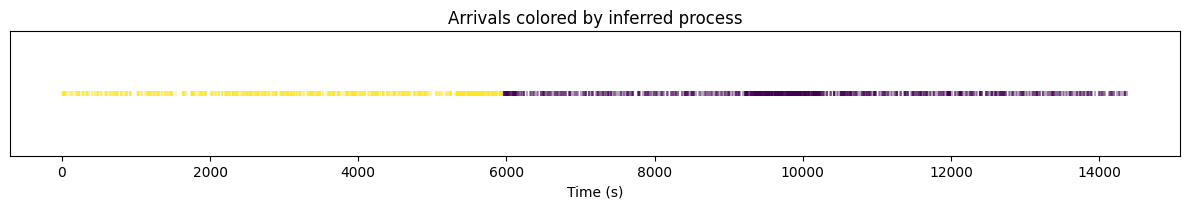

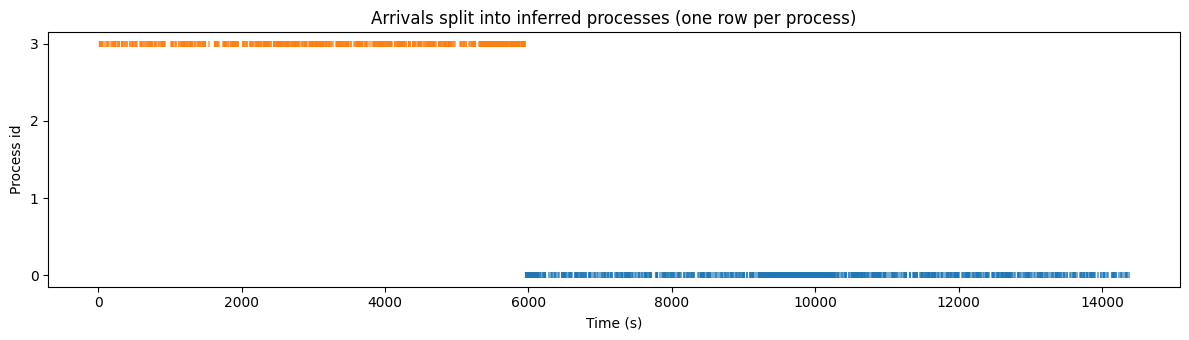

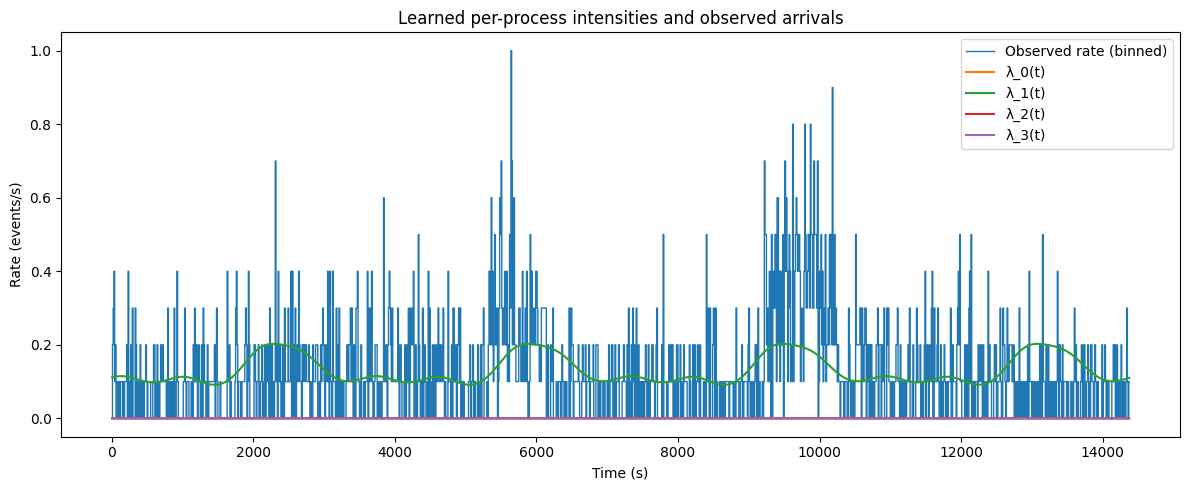

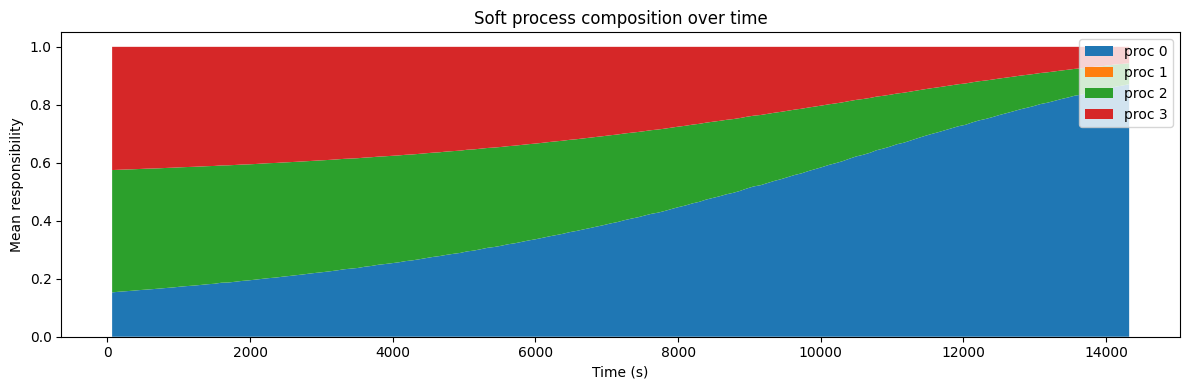

In [16]:
df = df.copy()
df["process_id"] = result.hard_assignments  # from fit_mixture_nhpp_em

plot_arrivals_raster(df, "rel_start_time_s")
plot_arrivals_per_process_rows(df, "rel_start_time_s")

plot_intensities_with_counts(df, "rel_start_time_s", result)

plot_soft_assignments_over_time(df, "rel_start_time_s", result, bins=150)
plt.show()
